# INFEWS Farm Model

## Objective and Prerequisites

This model is based of the example of a stochastic optimization problem from [Gurobi](https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/). That problem asked you to consider a situation where you have to buy today the stock of products to sell tomorrow but you don't know the exact demand you will see. Then you will have to decide what to do with whatever is left which includes selling it for scrap. This is called the Newspaper Vendor Problem. 


---
## Problem Description

For our problem a farm must decide how to prepare for different climate futures. Each climate future has different precipation patterns that will affect how much irrigation water is needed for different plants. Our farm must decide if and how much alternative water and electricity to invest in 
e simplified version of this problem, we have ten end customers zipcodes, each with a known demand for the vaccine.  Customer demand can be satisfied from a set of five depots.  Each depots can support a maximum volume of product moving through it, and each producer can supply a maximum amount of product.  There are known costs associated with transporting the product, from a producer to a depot (vaccine cost + a universal shipping fee) and from a distrubutor to a customer.

Our supply network has one producer that produces the vaccine.  Each has a maximum supply capacity:

| Producer | Supply (vaccines) |
| --- | --- |
| Producer |  500,000 |

The product can be shipped from the producer to a set of five depots.  Each depot has a maximum throughput.  Depots don't produce or consume the product; they simply pass the product on to customers.

| Depot | Throughput (vaccines) |
| --- | --- |
| D1 | 70,000 |
| D2 | 50,000 |
| D3 | 100,000 |
| D4 | 40,000 |
| D5 | 250,000 |

Our network has ten customers, each with a given demand.

| Customer | Demand (vaccines) |
| --- | --- |
| C1 | 50,000 |
| C2 | 10,000 |
| C3 | 40,000 |
| C4 | 35,000 |
| C5 | 60,000 |
| C6 | 20,000 |
| C7 | 45,000 |
| C8 | 52,000 |
| C9 | 65,000 |
| C10 | 27,000 |

Shipping costs are given in the following table (in dollars per mile).  Columns are sources (producers and depots) and rows are destinations (depots and customers).  

| To | Producer | D1 | D2 | D3 | D4 | D5 |
| --- | --- | --- | --- | --- | --- | --- |
| Depots |
| D1  | 0.5 |   - |
| D2 | 0.5 | - |
| D3     | 1.0 | - |
| D4     | 0.2 | - |
| D5     | 0.2 | - |
| Customers |
| C1 | - | 2.0 |   - | 1.0 |   - |   - |
| C2 |   - |   - | 1.5 | 0.5 | 1.5 |   - |
| C3 |   - |   - | 0.5 | 0.5 | 2.0 | 0.2 |
| C4 |   - |   - | 1.5 | 1.0 |   - | 1.5 |
| C5 |   - |   - |   - | 0.5 | 0.5 | 0.5 |
| C6 |   - |   - | 1.0 |   - | 1.5 | 1.5 |
| C7 |   - |   - | 1.0 |   - | 1.5 | 1.5 |
| C8 |   - |   - | 1.0 |   - | 1.5 | 1.5 |
| C9 |   - |   - | 1.0 |   - | 1.5 | 1.5 |
| C10 |   - |   - | 1.0 |   - | 1.5 | 1.5 |

The question to be answered is how to satisfy the demands of the end customers while minimizing shipping costs.

---
## Model Formulation

### Sets and Indices

$f \in \text{Producers}=\{\text{Producer}\}$

$d \in \text{Depots}=\{\text{D1}, \text{D2}, \text{D3}, \text{D4}, \text{D5}\}$

$c \in \text{Customers}=\{\text{C1}, \text{C2}, \text{C3}, \text{C4}, \text{C5}, \text{C6}, \text{C7}, \text{C8}, \text{C9}, \text{C10}\}$

$\text{Sets} = \text{Producers} \cup \text{Depots} \cup \text{Customers}$

### Parameters

$\text{cost}_{s,t} \in \mathbb{R}^+$: Cost of shipping one ton from source $s$ to destination $t$.

$\text{supply}_f \in \mathbb{R}^+$: Maximum possible supply from producer $f$ (in tons).

$\text{through}_d \in \mathbb{R}^+$: Maximum possible flow through depot $d$ (in tons).

$\text{demand}_c \in \mathbb{R}^+$: Demand for vaccines at customer $c$ (in tons).

### Decision Variables

$\text{flow}_{s,t} \in \mathbb{N}^+$: Quantity of vaccines that is shipped from source $s$ to destionation $t$.


### Objective Function

- **Cost**: Minimize total shipping costs.

\begin{equation}
\text{Minimize} \quad Z = \sum_{(s,t) \in \text{Sets} \times \text{Sets}}{\text{cost}_{s,t}*\text{flow}_{s,t}+\text{penalty}_{c}*\text{deficit}_{c}}
\end{equation}

### Constraints

- **Producer output**: Flow of goods from a producer must respect maximum capacity.

\begin{equation}
\sum_{t \in \text{Sets}}{\text{flow}_{f,t}} \leq \text{supply}_{f} \quad \forall f \in \text{Producers}
\end{equation}

- **Customer demand**: Flow of goods must meet customer demand.

\begin{equation}
\sum_{s \in \text{Sets}}{\text{flow}_{s,c}+\text{deficit}_{c}} = \text{demand}_{c} \quad \forall c \in \text{Customers}
\end{equation}

- **Depot flow**: Flow into a depot equals flow out of the depot.

\begin{equation}
\sum_{s \in \text{Sets}}{\text{flow}_{s,d}} = 
\sum_{t \in \text{Sets}}{\text{flow}_{d,t}}
\quad \forall d \in \text{Depots}
\end{equation}

- **Depot capacity**: Flow into a depot must respect depot capacity.

\begin{equation}
\sum_{s \in \text{Cities}}{\text{flow}_{s,d}} \leq \text{through}_{d}
\quad \forall d \in \text{Depots}
\end{equation}

---
## Python Implementation

We import the Gurobi Python Module and other Python libraries.

Import Libraries, Helpful Links, and Making Sure all Results show after each chunk.

In [1]:
from gurobipy import *
import random
random.seed(a=100)
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import gridspec
from matplotlib.ticker import PercentFormatter
import numpy as np
import scipy.stats as stats 


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Problem Source: https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/
# Matplotlib documentation: https://matplotlib.org/tutorials/introductory/pyplot.html
# Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html

Some helpful conversions.
And some parameterization and upper and lower bounds.

In [2]:
# Conversions

cm2_ha = 100000000 # 100,000,000 cm2 = 1 ha

cm3_gal = 3785.41 # 3785.41 cm2 = 1 Gal

gal_acre_ft = 325851 # 1 acre ft = 325851 gallons

acre_ha = 2.47105 # 1 hectare = 2.47105 acres

cm_ft = 30.48 # 1 ft = 30.48 cm

cm_in = 2.54

lb_tonne = 2204.62

# Parameters

ha = 10 # hectares

price = 200 # $/ metric ton #https://www.indexmundi.com/commodities/?commodity=wheat

#note $ /acre ranges from $7-85 / acre assuming only a few cm of depth similiar price to irrigation water 

cost_alt_water = 60 # $ / cm



# Irrigation Water Cost https://news.berkeley.edu/berkeley_blog/the-cost-of-irrigation-water-and-urban-farming/
#  Given in $ / cm from: $ 40 / acre-ft / gal_acre_ft / cm3_gal * cm2_ha * ha 

cost_irrigation_water = 40 / gal_acre_ft / cm3_gal * cm2_ha * ha  # $ / cm 


salt_conc = 2 # deciSiemens / meter = dS/m

salt_conc_water = 1 # deciSiemens / meter = dS/m

precip = 20 * cm_in # 20 inches of rain


irrigation_water_limit = 0.75 # acre-ft / acre https://www.nass.usda.gov/Publications/Highlights/2019/2017Census_Irrigation_and_WaterManagement.pdf

max_irrigation_water = irrigation_water_limit * cm_ft




Seeting the precipatation values.

This is where I can create climate regimes. 

Have certain climate regimes have certain values of precipatation

In [3]:

precip = np.array(range(25))
precip
len(precip)
samples = len(precip)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

25

A quick chart showing the effect of water depth on yield and price.

Text(0.5, 1.0, 'Profit and Yield by Preciptation')

Text(0.5, 0, 'Water Depth (cm)')

Text(0, 0.5, 'Profit ($)')

(-100.0, 7200.0)

Text(0, 0.5, 'Yield (tonnes/ha)')

(-100.0, 8500.0)

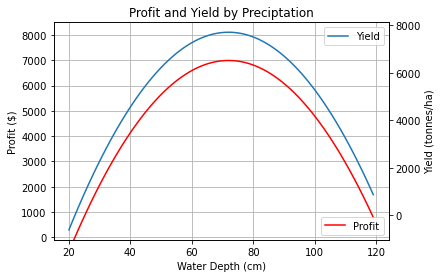

In [4]:
alt_water = 0
irrigation_water = 0
#irrigation_water = np.array(range(100))
water = np.array(range(100))+20
#water = alt_water + irrigation_water + precip

y1 = (-3.350 + 0.2064*water - 0.0014*water*water + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water 
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc
               -0.071 * water * salt_conc_water + 0.033 * water * salt_conc 
               -2.754 * salt_conc_water * salt_conc)

p1 = (y1*ha*price +
              -alt_water * (ha*cm2_ha/cm3_gal) * cost_alt_water +
              -irrigation_water * (ha*cm2_ha/cm3_gal) * cost_irrigation_water )

fig, ax = plt.subplots()

ax.plot(water,p1, label = 'Profit', color = 'red') # profit is red line
ax.set_title('Profit and Yield by Preciptation')
ax.set_xlabel('Water Depth (cm)')
ax.set_ylabel('Profit ($)')
ax.set_ylim([-100,7200])
ax.grid(True)
ax.legend(loc = 'lower right')

ax2 = ax.twinx()
ax2.plot(water,y1*lb_tonne, label = 'Yield') # yield is blue line
ax2.set_ylabel('Yield (tonnes/ha)')
ax.set_ylim([-100,8500])
ax2.legend()
plt.show()


#plt.plot(irrigation_water,p1)








Another useful bound to speed up computational time. The max price is as good as it gets and since the above code doesn't have any cost max price is max rev.

In [29]:
# To help get tight bounds on variables later on

maxrev  = max(p1)
minrev  = 0


6992.400000000002

This code defines the charts that are used in the other Stochastic programs.

In [7]:
# Conditional value at risk (for losses) is the expected value of the worst alpha% tail of the realizations 
# in the random variable (represented in this case as a list of values)
# alpha: a value in ]0,1[
# data: a list of values
def CVaR(data,alpha):
    data.sort()
    n = len(data)
    m = int(alpha*n)
    return sum(data[m:-1])/len(data[m:-1])

# Prints the double histogram of a random variable (represented in this case as a list of values)
# First the empirical density distribution, and then the empirical accumulated probability

n_bins = 150

def doubleHist(data, xlabel=None):
    plt.figure(figsize=(14.5,6),dpi=600)
    gs  = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.25)
    ax  = plt.subplot(gs[0])
    ax3 = plt.subplot(gs[1])
    ax.grid(True)
    ax.set_title(xlabel)
    ax.set_ylabel('Likelihood of occurrence',color='blue')
    ax2 = ax.twinx()
    ax2.set_ylabel('Cumulative probability',color='red')
    # plot the density and cumulative histogram
    n, bins, patches = ax.hist(data, n_bins, density=True, alpha=0.65, cumulative=False, label='Density', color='blue')
    n, bins, patches = ax2.hist(data, n_bins, density=True, histtype='step', cumulative=True, label='CDF', color='red')
    ax3.boxplot(data,whis=[5,95])
    # tidy up the figure
    plt.show()

#print basic info on optimal solution
def solutionStats(model, order, losses):
    global cost_alt_water
    losses.sort()
    samples = len(losses)
    print('Model Value', m.ObjVal, 'order Qty', alt_water.X, 'investment', alt_water.X*cost_alt_water, '#samples',samples)
    print('Losses stats:')
    print('CVaR(95%,90%,80%,70%)', CVaR(losses,0.95), CVaR(losses,0.90), CVaR(losses, 0.80), CVaR(losses,0.70))
    print('min', min(losses),'max', max(losses), 'average', sum(losses)/samples, 'VaR_75%', losses[int(0.75*samples)])

Defines the stochastic model. This model is simply a weighted average. Takes each possible precipatation and its corresponding yield and profit and averages them equally.

Variabels

alt_water; irrigation_water

water

crop_yield, profit

Objective functions are all profit and correspond to the different precipation scenarios. Need to change this to climaate scenarios.

Water is function of precipitation, alternative water and irrigation water.

Crop yield is function of saliniatity, soil, and water.


In [5]:
m = Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions

alt_water = m.addVar(name = 'alt_water') # cm of depth
irrigation_water = m.addVar(ub = max_irrigation_water, name = 'irrigation_water') # cm of depth

#Second Stage Decision Variables Operational Decisions
water = m.addVars(samples,name = 'water') # water used for crop, cm of depth

#Functions of the ABove
crop_yield = m.addVars(samples,name = 'yield') # tonne/ha
profit = m.addVars(samples,obj = 1.0/len(precip), name = 'profit') # $


# Objective

m.addConstrs( (profit[i] == crop_yield[i] * ha * price +
              -alt_water * cost_alt_water +
              -irrigation_water * cost_irrigation_water
             for i in range(samples) )
            ,name = 'profit')
# Set Constraints



m.addConstrs( (precip[i] + alt_water + irrigation_water >= water[i]  
              for i in range(samples) )
            ,name = 'water' )

for i in range(samples):
    m.addQConstr( (crop_yield[i] <= -3.350 + 0.2064*water[i] - 0.0014*water[i]*water[i] + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[i] * salt_conc_water + 0.033 * water[i] * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();



Using license file C:\Users\Jones\gurobi.lic
Academic license - for non-commercial use only


In [6]:
m.optimize()

Gurobi Optimizer version 9.0.3 build v9.0.3rc0 (win64)
Optimize a model with 50 rows, 77 columns and 175 nonzeros
Model fingerprint: 0x8c527a71
Model has 25 quadratic constraints
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [4e-02, 4e-02]
  Bounds range     [2e+01, 2e+01]
  RHS range        [1e+00, 2e+01]
  QRHS range       [4e+00, 4e+00]
Presolve time: 0.01s
Presolved: 125 rows, 127 columns, 325 nonzeros
Presolved model has 25 second-order cone constraints
Ordering time: 0.00s

Barrier statistics:
 Dense cols : 2
 AA' NZ     : 2.750e+02
 Factor NZ  : 6.280e+02
 Factor Ops : 3.380e+03 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   3.78405887e+02  5.88328099e+01  3.48e+01 2.73e+00  2.19e+01     0s
   1   5.86723395e+02  2.90174432e+01  1.79e+01 1.20e+00

Showing all the results for each precipation scenario. Need to change this to climate scenario.

In [8]:
profit
crop_yield
irrigation_water
alt_water
water

{0: <gurobi.Var profit[0] (value 3229.866825800719)>,
 1: <gurobi.Var profit[1] (value 3353.877722841914)>,
 2: <gurobi.Var profit[2] (value 3472.2886188965526)>,
 3: <gurobi.Var profit[3] (value 3585.0995156907725)>,
 4: <gurobi.Var profit[4] (value 3692.310392621862)>,
 5: <gurobi.Var profit[5] (value 3793.9213087634216)>,
 6: <gurobi.Var profit[6] (value 3889.932203019632)>,
 7: <gurobi.Var profit[7] (value 3980.343098902318)>,
 8: <gurobi.Var profit[8] (value 4065.153994522112)>,
 9: <gurobi.Var profit[9] (value 4144.364889792209)>,
 10: <gurobi.Var profit[10] (value 4217.975784572701)>,
 11: <gurobi.Var profit[11] (value 4285.986679131338)>,
 12: <gurobi.Var profit[12] (value 4348.397574895727)>,
 13: <gurobi.Var profit[13] (value 4405.20847224282)>,
 14: <gurobi.Var profit[14] (value 4456.419369669884)>,
 15: <gurobi.Var profit[15] (value 4502.03026658816)>,
 16: <gurobi.Var profit[16] (value 4542.041163122787)>,
 17: <gurobi.Var profit[17] (value 4576.452059448463)>,
 18: <gurob

{0: <gurobi.Var yield[0] (value 2.7783052036970624)>,
 1: <gurobi.Var yield[1] (value 2.84031065221766)>,
 2: <gurobi.Var yield[2] (value 2.8995161002449787)>,
 3: <gurobi.Var yield[3] (value 2.955921548642089)>,
 4: <gurobi.Var yield[4] (value 3.0095269871076336)>,
 5: <gurobi.Var yield[5] (value 3.060332445178413)>,
 6: <gurobi.Var yield[6] (value 3.1083378923065186)>,
 7: <gurobi.Var yield[7] (value 3.1535433402478614)>,
 8: <gurobi.Var yield[8] (value 3.1959487880577586)>,
 9: <gurobi.Var yield[9] (value 3.2355542356928075)>,
 10: <gurobi.Var yield[10] (value 3.272359683083053)>,
 11: <gurobi.Var yield[11] (value 3.306365130362372)>,
 12: <gurobi.Var yield[12] (value 3.3375705782445664)>,
 13: <gurobi.Var yield[13] (value 3.365976026918113)>,
 14: <gurobi.Var yield[14] (value 3.3915814756316447)>,
 15: <gurobi.Var yield[15] (value 3.414386924090783)>,
 16: <gurobi.Var yield[16] (value 3.4343923723580967)>,
 17: <gurobi.Var yield[17] (value 3.4515978205209343)>,
 18: <gurobi.Var yie

<gurobi.Var irrigation_water (value 22.859999996174388)>

<gurobi.Var alt_water (value 26.423768548982643)>

{0: <gurobi.Var water[0] (value 49.28376852424676)>,
 1: <gurobi.Var water[1] (value 50.28376852378325)>,
 2: <gurobi.Var water[2] (value 51.28376852198443)>,
 3: <gurobi.Var water[3] (value 52.28376852101608)>,
 4: <gurobi.Var water[4] (value 53.28376851832391)>,
 5: <gurobi.Var water[5] (value 54.283768518397046)>,
 6: <gurobi.Var water[6] (value 55.28376851665113)>,
 7: <gurobi.Var water[7] (value 56.28376851495642)>,
 8: <gurobi.Var water[8] (value 57.28376851226833)>,
 9: <gurobi.Var water[9] (value 58.28376851025822)>,
 10: <gurobi.Var water[10] (value 59.28376850744327)>,
 11: <gurobi.Var water[11] (value 60.28376850435208)>,
 12: <gurobi.Var water[12] (value 61.283768500110554)>,
 13: <gurobi.Var water[13] (value 62.2837684959313)>,
 14: <gurobi.Var water[14] (value 63.283768490504876)>,
 15: <gurobi.Var water[15] (value 64.2837684829127)>,
 16: <gurobi.Var water[16] (value 65.28376847404265)>,
 17: <gurobi.Var water[17] (value 66.28376846121539)>,
 18: <gurobi.Var water[18] (v

Showing results of Profit Expected Value for CVaR 95%.

In [9]:
losses= [-profit[i].X for i in range(samples)]
sol1 = losses.copy()

In [10]:
alpha = 0.95
len(losses)
int(alpha*len(losses))
CVaR(losses,alpha)

25

23

-3353.877722841914

Model Value 4203.017403107337 order Qty 26.423768548982643 investment 1585.4261129389586 #samples 25
Losses stats:
CVaR(95%,90%,80%,70%) -3353.877722841914 -3413.083170869233 -3525.8940625127752 -3681.110408676639
min -4665.670701318402 max -3229.866825800719 average -4203.017403107337 VaR_75% -3889.932203019632


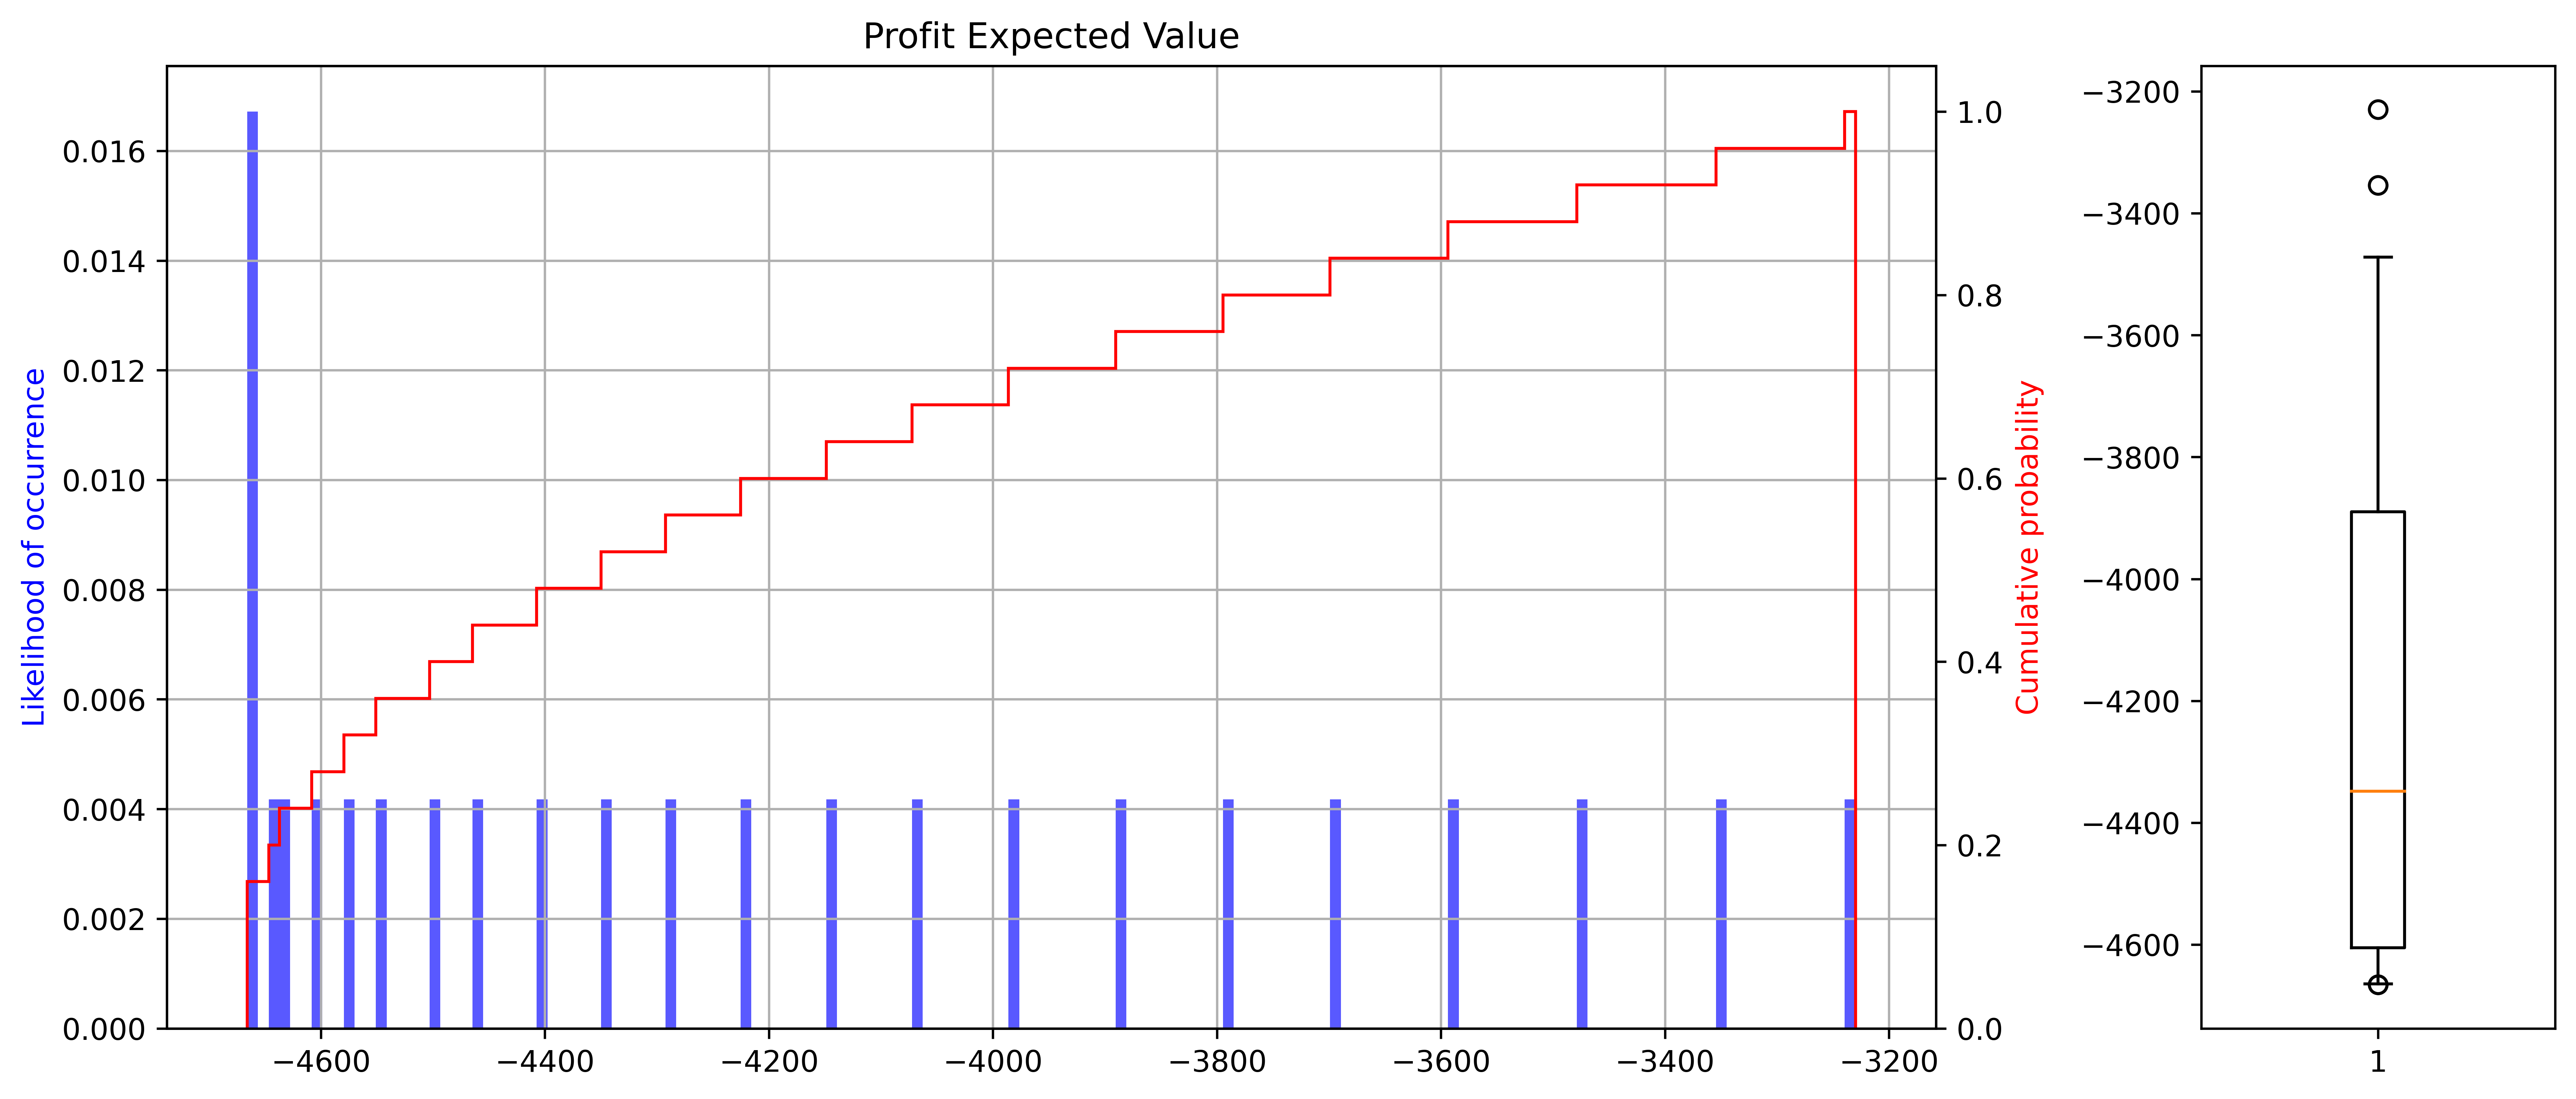

In [11]:
solutionStats(m, alt_water, sol1)
doubleHist(sol1, xlabel='Profit Expected Value')

The second model where the CVaR is 75%. Instead of a weighted average model which Takes each possible precipatation and its corresponding yield and profit and averages them equally. This model uses the CVaR method.


In [55]:
m = Model()

# Set to maximize
m.ModelSense = -1

# Add variables
crop_yield = m.addVars(samples,name = 'yield') # tonne/ha
alt_water = m.addVar(name = 'alt_water') # cm of depth
irrigation_water = m.addVar(ub = max_irrigation_water, name = 'irrigation_water') # cm of depth
profit = m.addVars(samples,obj = 0/len(precip), name = 'profit') # $
water = m.addVars(samples,name = 'water') # water used for crop, cm of depth

#CVaR Variables
alpha = 0.75
nu = m.addVar(obj=-1, lb = minrev, ub = maxrev, name='worst')
excess   = m.addVars(samples,obj=-1.0/((1-alpha)*samples), ub = maxrev-minrev, name='chance')

# Objective

m.addConstrs( (profit[i] == crop_yield[i] * ha * price +
              -alt_water * cost_alt_water +
              -irrigation_water * cost_irrigation_water
             for i in range(samples) )
            ,name = 'profit')
# Set Constraints



m.addConstrs( (precip[i] + alt_water + irrigation_water >= water[i]  
              for i in range(samples) )
            ,name = 'water' )

for i in range(samples):
    m.addQConstr( (crop_yield[i] <= -3.350 + 0.2064*water[i] - 0.0014*water[i]*water[i] + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[i] * salt_conc_water + 0.033 * water[i] * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )
    
#CVaR Constraints

m.addConstrs((-profit[i]-nu <= excess[i] for i in range(samples)),name='excess')


m.update();


In [56]:
m.optimize()
obj = m.getObjective()
print(obj.getValue())

Gurobi Optimizer version 9.0.3 build v9.0.3rc0 (win64)
Optimize a model with 75 rows, 103 columns and 250 nonzeros
Model fingerprint: 0x61936555
Model has 25 quadratic constraints
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [2e-01, 1e+00]
  Bounds range     [2e+01, 7e+03]
  RHS range        [1e+00, 2e+01]
  QRHS range       [4e+00, 4e+00]
Presolve removed 25 rows and 51 columns
Presolve time: 0.01s
Presolved: 125 rows, 102 columns, 300 nonzeros
Presolved model has 25 second-order cone constraints
Ordering time: 0.00s

Barrier statistics:
 Dense cols : 2
 AA' NZ     : 2.750e+02
 Factor NZ  : 6.280e+02
 Factor Ops : 3.380e+03 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0  -0.00000000e+00  2.28600000e+00  2.29e+01 1.00e-01  8.76e-01     0s
   1  -0.000000

In [57]:
profit
crop_yield
irrigation_water
alt_water
water

excess_values = [excess[i].X for i in range(samples)]
print('max and min excess values')
max(excess_values)
min(excess_values)
print('max and min revenue values')
maxrev
minrev
print('Nu:')
nu
print('Max and Min Profit')
profits = [profit[i].X for i in range(samples)]
max(profits)
min(profits)
print('Objective Value')
obj = m.getObjective()
print(obj.getValue())

{0: <gurobi.Var profit[0] (value 444.17521379114487)>,
 1: <gurobi.Var profit[1] (value 322.50129125733065)>,
 2: <gurobi.Var profit[2] (value 308.51209980780413)>,
 3: <gurobi.Var profit[3] (value 308.2588312030084)>,
 4: <gurobi.Var profit[4] (value 310.89896463780497)>,
 5: <gurobi.Var profit[5] (value 313.88477990991214)>,
 6: <gurobi.Var profit[6] (value 316.8135244866055)>,
 7: <gurobi.Var profit[7] (value 319.31989343512487)>,
 8: <gurobi.Var profit[8] (value 321.50686075770705)>,
 9: <gurobi.Var profit[9] (value 323.5458412377993)>,
 10: <gurobi.Var profit[10] (value 325.28953975188483)>,
 11: <gurobi.Var profit[11] (value 326.79468688011775)>,
 12: <gurobi.Var profit[12] (value 328.10600652339804)>,
 13: <gurobi.Var profit[13] (value 329.2579384065891)>,
 14: <gurobi.Var profit[14] (value 330.2745242975898)>,
 15: <gurobi.Var profit[15] (value 331.18210623098275)>,
 16: <gurobi.Var profit[16] (value 331.9978721872476)>,
 17: <gurobi.Var profit[17] (value 332.7356215148709)>,
 

{0: <gurobi.Var yield[0] (value 1.057378838534082)>,
 1: <gurobi.Var yield[1] (value 0.9965418772671751)>,
 2: <gurobi.Var yield[2] (value 0.9895472815424119)>,
 3: <gurobi.Var yield[3] (value 0.989420647240014)>,
 4: <gurobi.Var yield[4] (value 0.9907407139574123)>,
 5: <gurobi.Var yield[5] (value 0.9922336215934658)>,
 6: <gurobi.Var yield[6] (value 0.9936979938818126)>,
 7: <gurobi.Var yield[7] (value 0.9949511783560722)>,
 8: <gurobi.Var yield[8] (value 0.9960446620173633)>,
 9: <gurobi.Var yield[9] (value 0.9970641522574094)>,
 10: <gurobi.Var yield[10] (value 0.9979360015144522)>,
 11: <gurobi.Var yield[11] (value 0.9986885750785687)>,
 12: <gurobi.Var yield[12] (value 0.9993442349002087)>,
 13: <gurobi.Var yield[13] (value 0.9999202008418043)>,
 14: <gurobi.Var yield[14] (value 1.0004284937873047)>,
 15: <gurobi.Var yield[15] (value 1.000882284754001)>,
 16: <gurobi.Var yield[16] (value 1.0012901677321335)>,
 17: <gurobi.Var yield[17] (value 1.0016590423959453)>,
 18: <gurobi.Va

<gurobi.Var irrigation_water (value 22.52573415450271)>

<gurobi.Var alt_water (value 15.668412718517914)>

{0: <gurobi.Var water[0] (value 36.90445451953922)>,
 1: <gurobi.Var water[1] (value 37.574058331858055)>,
 2: <gurobi.Var water[2] (value 38.211326272961784)>,
 3: <gurobi.Var water[3] (value 38.86193791373364)>,
 4: <gurobi.Var water[4] (value 39.452688150844246)>,
 5: <gurobi.Var water[5] (value 39.99591700820552)>,
 6: <gurobi.Var water[6] (value 40.51078051010537)>,
 7: <gurobi.Var water[7] (value 41.00780528377081)>,
 8: <gurobi.Var water[8] (value 41.493012556566164)>,
 9: <gurobi.Var water[9] (value 41.96963688740602)>,
 10: <gurobi.Var water[10] (value 42.43917310660799)>,
 11: <gurobi.Var water[11] (value 42.90250091706241)>,
 12: <gurobi.Var water[12] (value 43.36006669449979)>,
 13: <gurobi.Var water[13] (value 43.81205181577822)>,
 14: <gurobi.Var water[14] (value 44.25835306794948)>,
 15: <gurobi.Var water[15] (value 44.69935705297737)>,
 16: <gurobi.Var water[16] (value 45.135088186499715)>,
 17: <gurobi.Var water[17] (value 45.56556841180106)>,
 18: <gurobi.Var water[18

...

<gurobi.Var worst (value 0.0)>

Max and Min Profit


444.17521379114487

308.2588312030084

Objective Value
0.0


In [58]:
losses= [-profit[i].X for i in range(samples)]
sol2 = losses.copy()

Model Value -0.0 order Qty 15.668412718517914 investment 940.1047631110748 #samples 25
Losses stats:
CVaR(95%,90%,80%,70%) -308.51209980780413 -309.70553222280455 -312.5273422105317 -316.2053448988985
min -444.17521379114487 max -308.2588312030084 average -330.8088872399024 VaR_75% -321.50686075770705


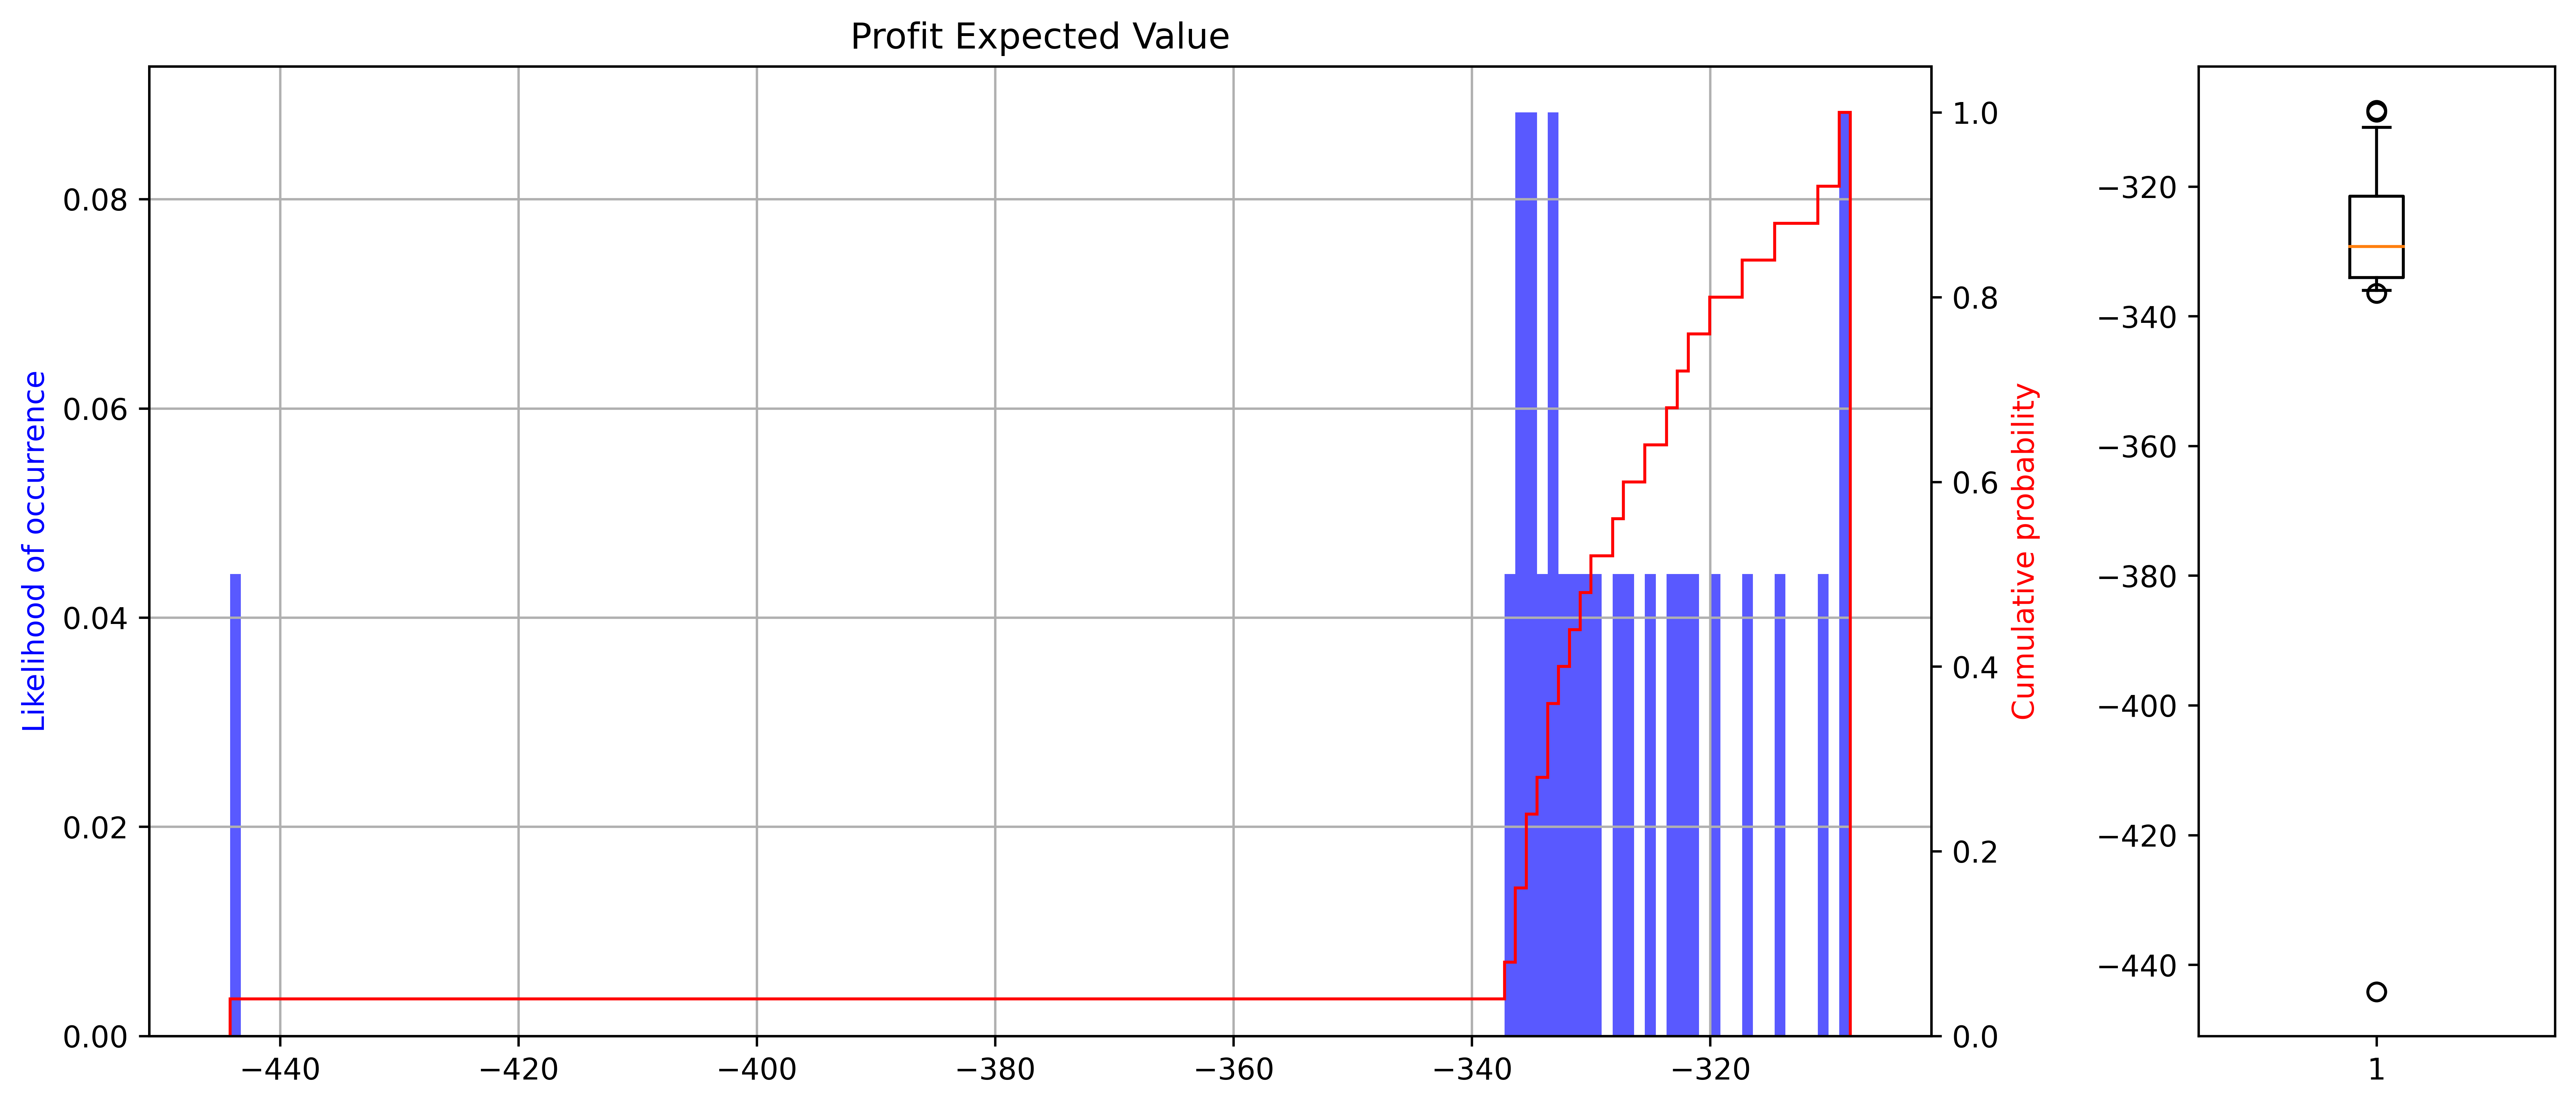

In [60]:
solutionStats(m, alt_water, sol2)
doubleHist(sol2, xlabel='Losses CVaR 75%')

The just CVaR method didn't work out to hot so I did a mix of 50% CVAR 75% and 50% mix of just a weighted average.

In [66]:
# Maximize 50 % CVaR_0.75 profit and 20% expected return
beta  = 0.50
alpha = 0.75


m = Model()

# Set to maximize
m.ModelSense = -1

# Add variables
crop_yield = m.addVars(samples,name = 'yield') # tonne/ha
alt_water = m.addVar(name = 'alt_water') # cm of depth
irrigation_water = m.addVar(ub = max_irrigation_water, name = 'irrigation_water') # cm of depth
profit = m.addVars(samples,obj = (1-beta)/len(precip), name = 'profit') # $
water = m.addVars(samples,name = 'water') # water used for crop, cm of depth

#CVaR Variables
alpha = 0.75
nu = m.addVar(obj=-beta, lb = minrev, ub = maxrev, name='worst')
excess   = m.addVars(samples,obj=-beta/((1-alpha)*samples), ub = maxrev-minrev, name='chance')

# Objective

m.addConstrs( (profit[i] == crop_yield[i] * ha * price +
              -alt_water * cost_alt_water +
              -irrigation_water * cost_irrigation_water
             for i in range(samples) )
            ,name = 'profit')
# Set Constraints



m.addConstrs( (precip[i] + alt_water + irrigation_water >= water[i]  
              for i in range(samples) )
            ,name = 'water' )

for i in range(samples):
    m.addQConstr( (crop_yield[i] <= -3.350 + 0.2064*water[i] - 0.0014*water[i]*water[i] + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[i] * salt_conc_water + 0.033 * water[i] * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )
    
#CVaR Constraints

m.addConstrs((-profit[i]-nu <= excess[i] for i in range(samples)),name='excess')


m.update();

In [67]:
m.optimize()

Gurobi Optimizer version 9.0.3 build v9.0.3rc0 (win64)
Optimize a model with 75 rows, 103 columns and 250 nonzeros
Model fingerprint: 0x9a8c8534
Model has 25 quadratic constraints
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [2e-02, 5e-01]
  Bounds range     [2e+01, 7e+03]
  RHS range        [1e+00, 2e+01]
  QRHS range       [4e+00, 4e+00]
Presolve removed 25 rows and 26 columns
Presolve time: 0.01s
Presolved: 125 rows, 127 columns, 325 nonzeros
Presolved model has 25 second-order cone constraints
Ordering time: 0.00s

Barrier statistics:
 Dense cols : 2
 AA' NZ     : 2.750e+02
 Factor NZ  : 6.280e+02
 Factor Ops : 3.380e+03 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   1.89202943e+02  2.94164049e+01  3.48e+01 1.36e+00  1.09e+01     0s
   1   2.933616

In [68]:
losses= [-profit[i].X for i in range(samples)]
sol3 = losses.copy()

Model Value 2101.5087015536665 order Qty 26.423768548990665 investment 1585.42611293944 #samples 25
Losses stats:
CVaR(95%,90%,80%,70%) -3353.877722842436 -3413.083170869706 -3525.8940625131927 -3681.1104086769924
min -4665.670701317916 max -3229.866825801263 average -4203.017403107332 VaR_75% -3889.9322030198928


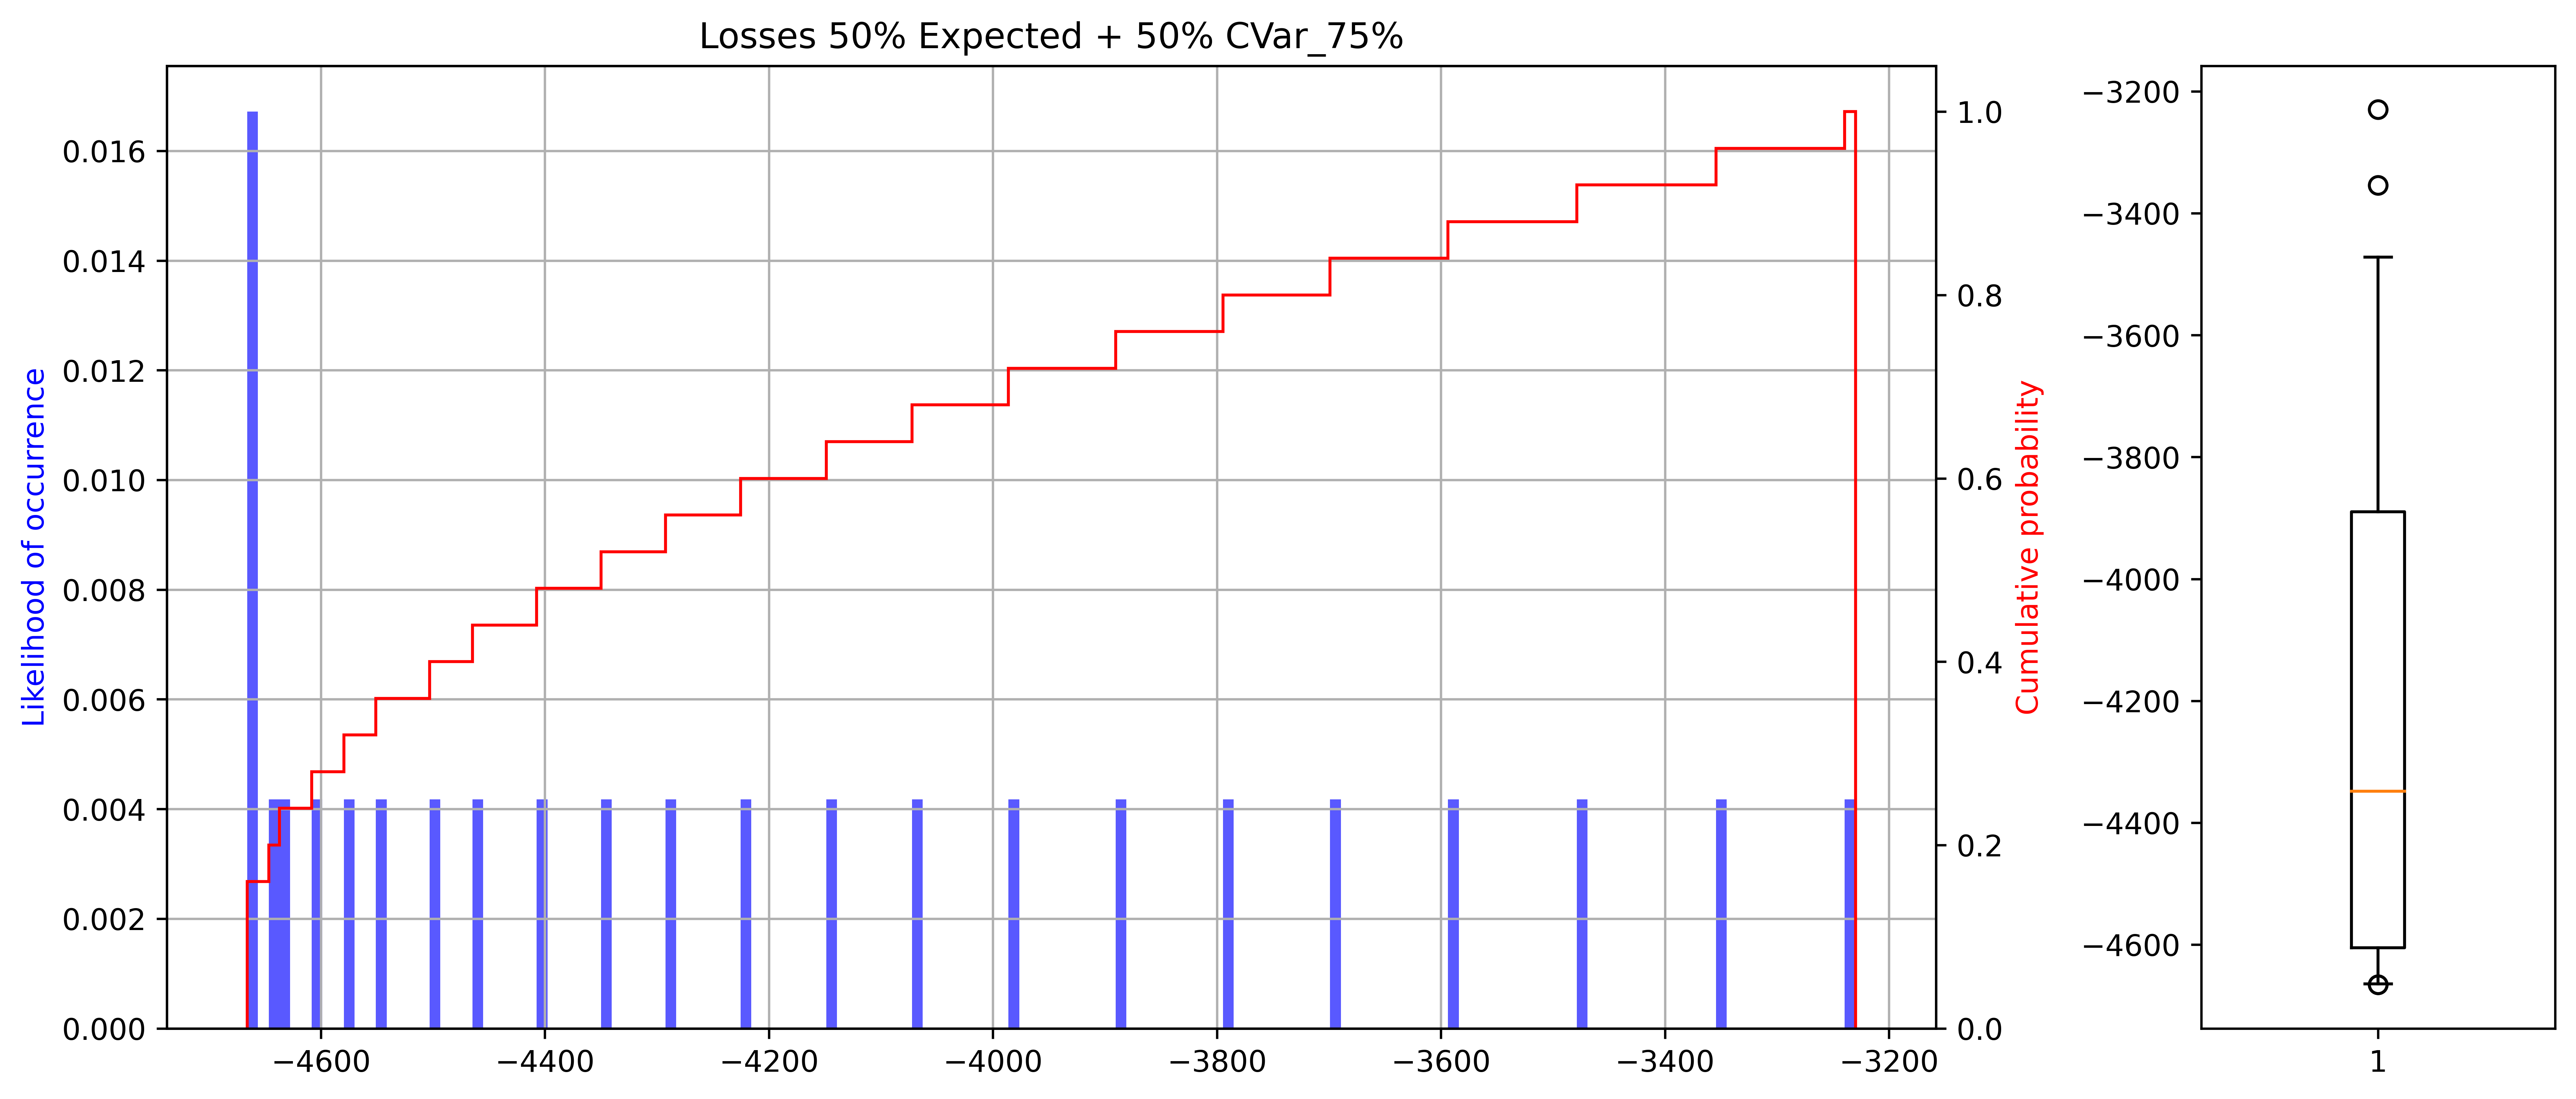

In [69]:
solutionStats(m, alt_water, sol3)
doubleHist(sol3, xlabel='Losses 50% Expected + 50% CVar_75%')